In [4]:
# 1) Imports & path setup
import pandas as pd
from pathlib import Path

# adjust to wherever your .parquet files live
data_dir = Path("../data")  

# 2) Read & concat all Parquet logs
parquets = list(data_dir.glob("*.parquet"))
print(f"Found {len(parquets)} files:")
for p in parquets: print("  ", p.name)

dfs = [pd.read_parquet(p) for p in parquets]
df_all = pd.concat(dfs, ignore_index=True)
print(f"\nCombined DataFrame shape: {df_all.shape}")

# 3) Create a binary “is‑attack” column
df_all["attack_binary"] = (df_all["Label"].str.lower() != "benign").astype(int)

# 4) Quick sanity‑check
print("\nLabel counts (raw):")
print(df_all["Label"].value_counts())
print("\nBinary attack counts:")
print(df_all["attack_binary"].value_counts())


#What this does:
# Splits once so that both stages see exactly the same train/test.
# Stage 1: flags benign vs. attack.
# Stage 2: only for those flagged as attack, runs the multi‑class XGBoost to pick the exact attack label.
# End‑to‑End: compares the combined result against the original Label (including “benign”) and prints a single report + confusion matrix.

# 5) End‑to‑End Hierarchical Pipeline Evaluation
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# —————————————————————————————————————————————————————————————————————
# a) Build features, binary & multiclass targets, then split once
# —————————————————————————————————————————————————————————————————————
X   = df_all.drop(columns=['Label','attack_binary'])
y_b = df_all['attack_binary']       # 0=benign, 1=any attack
y_m = df_all['Label']               # 'benign' or attack name

# stratify on the binary target so we retain the same ratio of attacks
X_tr, X_te, yb_tr, yb_te, ym_tr, ym_te = train_test_split(
    X, y_b, y_m,
    test_size=0.20,
    stratify=y_b,
    random_state=42
)

print(f"▶ Train/​Test sizes: {X_tr.shape} / {X_te.shape}")
print("   Binary balance (train):", np.bincount(yb_tr)/len(yb_tr))
print("   Binary balance ( test):", np.bincount(yb_te)/len(yb_te), "\n")

# —————————————————————————————————————————————————————————————————————
# b) Stage 1: Attack vs. benign
# —————————————————————————————————————————————————————————————————————
clf_bin = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False,
    n_jobs=-1
)
t0 = time.time()
clf_bin.fit(X_tr, yb_tr)
t_bin = time.time()-t0

yb_pred = clf_bin.predict(X_te)

print(f"Stage 1 (binary) train time: {t_bin:.2f}s")
print(classification_report(yb_te, yb_pred, target_names=['benign','attack'], digits=4), "\n")

# —————————————————————————————————————————————————————————————————————
# c) Stage 2: if attack, which type?
# —————————————————————————————————————————————————————————————————————
# factorize the multi‑class labels on the TRAINING split only
train_attacks = ym_tr != 'benign'
codes, uniques = pd.factorize(ym_tr[train_attacks])
# build a mapping from label→code
label2code = {lab: i for i,lab in enumerate(uniques)}

# integer‐encode only the attack rows
y_tr_codes = ym_tr.map(lambda L: label2code[L] if L!='benign' else -1)
mask_tr = y_tr_codes>=0

clf_multi = XGBClassifier(
    objective='multi:softprob',
    num_class=len(uniques),
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False,
    n_jobs=-1
)

# fit only on the attack subset of the training data
t0 = time.time()
clf_multi.fit(
    X_tr[mask_tr],
    y_tr_codes[mask_tr]
)
t_multi = time.time()-t0
print(f"Stage 2 (multi) train time: {t_multi:.2f}s\n")

# —————————————————————————————————————————————————————————————————————
# d) Inference on the TEST split
# —————————————————————————————————————————————————————————————————————
# 1) predict binary
yb_hat = clf_bin.predict(X_te)

# prepare an array of final labels, default 'benign'
y_hat_full = np.array(['benign']*len(X_te), dtype=object)

# 2) for those predicted as attack, run the multi‐class model
attack_idx = np.where(yb_hat==1)[0]
if attack_idx.size>0:
    X_attack = X_te.iloc[attack_idx]
    codes_hat = clf_multi.predict(X_attack)
    # map codes back to original attack names
    y_hat_full[attack_idx] = uniques[codes_hat]

# 3) true full labels on the test split
y_true_full = ym_te.values

# —————————————————————————————————————————————————————————————————————
# e) Final evaluation
# —————————————————————————————————————————————————————————————————————
print("▶ End‑to‑End Classification Report:\n")
print(classification_report(y_true_full, y_hat_full, digits=4))

print("▶ End‑to‑End Confusion Matrix:\n")
cm = confusion_matrix(y_true_full, y_hat_full, labels=np.concatenate([['benign'], uniques]))
cm_df = pd.DataFrame(cm, index=['benign']+list(uniques), columns=['benign']+list(uniques))
display(cm_df)


Found 10 files:
   DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet
   Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet
   Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet
   DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet
   Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet
   DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet
   DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet
   Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet
   Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet
   Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet

Combined DataFrame shape: (6659532, 78)

Label counts (raw):
Label
Benign                      5329008
DDoS attacks-LOIC-HTTP       575364
DDOS attack-HOIC             198861
DoS attacks-Hulk             145199
Bot                          144535
Infilteration                118483
SSH-Bruteforce                94048
DoS attacks-GoldenEye         4140

/Users/nanaue/miniforge3/envs/dsml/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [13:04:33] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744352353999/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Stage 1 (binary) train time: 17.87s
              precision    recall  f1-score   support

      benign     0.9789    0.9992    0.9889   1065802
      attack     0.9966    0.9136    0.9533    266105

    accuracy                         0.9821   1331907
   macro avg     0.9877    0.9564    0.9711   1331907
weighted avg     0.9824    0.9821    0.9818   1331907
 



/Users/nanaue/miniforge3/envs/dsml/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [13:04:54] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744352353999/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Stage 2 (multi) train time: 251.04s

▶ End‑to‑End Classification Report:



/Users/nanaue/miniforge3/envs/dsml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/nanaue/miniforge3/envs/dsml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/nanaue/miniforge3/envs/dsml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                          precision    recall  f1-score   support

                  Benign     0.5872    0.0002    0.0004   1065802
                     Bot     0.9998    0.9957    0.9977     29335
        Brute Force -Web     0.9836    0.4762    0.6417       126
        Brute Force -XSS     1.0000    0.6829    0.8116        41
        DDOS attack-HOIC     0.9998    0.9997    0.9997     39452
    DDOS attack-LOIC-UDP     0.8975    0.9153    0.9063       354
  DDoS attacks-LOIC-HTTP     0.9997    0.9994    0.9995    114983
   DoS attacks-GoldenEye     0.9999    0.9999    0.9999      8393
        DoS attacks-Hulk     1.0000    1.0000    1.0000     29004
DoS attacks-SlowHTTPTest     0.0769    0.0909    0.0833        11
   DoS attacks-Slowloris     0.9916    0.9950    0.9933      2011
          FTP-BruteForce     0.2308    0.2143    0.2222        14
           Infilteration     0.5912    0.0351    0.0663     23707
           SQL Injection     0.7500    0.4615    0.5714        13
         

,benign,Infilteration,Benign,DDoS attacks-LOIC-HTTP,SSH-Bruteforce,DoS attacks-Hulk,DDOS attack-HOIC,DoS attacks-GoldenEye,Bot,DDOS attack-LOIC-UDP,DoS attacks-Slowloris,Brute Force -Web,Brute Force -XSS,DoS attacks-SlowHTTPTest,SQL Injection,FTP-BruteForce
benign,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Infilteration,22733,833,141,0,0,0,0,0,0,0,0,0,0,0,0,0
Benign,1064964,576,229,3,0,0,9,1,1,0,17,1,0,0,1,0
DDoS attacks-LOIC-HTTP,34,0,1,114911,0,0,0,0,0,37,0,0,0,0,0,0
SSH-Bruteforce,6,0,0,0,18652,0,0,0,0,0,0,0,0,2,0,1
DoS attacks-Hulk,0,0,0,0,0,29004,0,0,0,0,0,0,0,0,0,0
DDOS attack-HOIC,4,0,7,0,0,0,39441,0,0,0,0,0,0,0,0,0
DoS attacks-GoldenEye,1,0,0,0,0,0,0,8392,0,0,0,0,0,0,0,0
Bot,126,0,1,0,0,0,0,0,29208,0,0,0,0,0,0,0
DDOS attack-LOIC-UDP,0,0,1,29,0,0,0,0,0,324,0,0,0,0,0,0


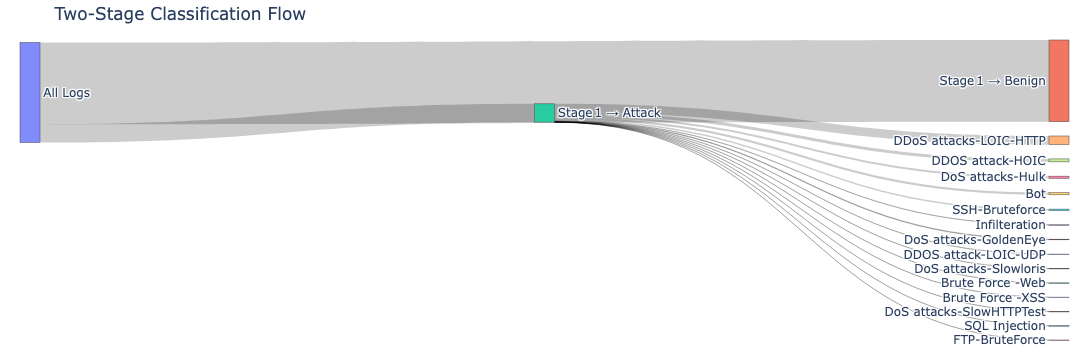

In [10]:
import numpy as np
import plotly.graph_objects as go

# —————————————————————————————————————————————————————————————————————
# 1) Stage 1 predictions (reuse clf_bin & X_te)
# —————————————————————————————————————————————————————————————————————
pred_bin = clf_bin.predict(X_te)

# —————————————————————————————————————————————————————————————————————
# 2) Build final predictions array
# —————————————————————————————————————————————————————————————————————
final_pred = np.array(['Benign'] * len(pred_bin), dtype=object)
attack_idxs = np.where(pred_bin == 1)[0]
if attack_idxs.size:
    codes = clf_multi.predict(X_te.iloc[attack_idxs])
    # 'uniques' came from your factorization of attack labels
    final_pred[attack_idxs] = uniques[codes]

# —————————————————————————————————————————————————————————————————————
# 3) Counts for Sankey
# —————————————————————————————————————————————————————————————————————
count_benign = int((pred_bin == 0).sum())
count_attack = int((pred_bin == 1).sum())

# Only keep true attack labels (exclude any “Benign” if it snuck in)
attack_labels = [lbl for lbl in uniques if lbl.lower() != 'benign']
attack_counts = {lbl: int((final_pred == lbl).sum()) for lbl in attack_labels}

# —————————————————————————————————————————————————————————————————————
# 4) Build nodes & links
# —————————————————————————————————————————————————————————————————————
labels = [
    'All Logs',
    'Stage 1 → Benign',
    'Stage 1 → Attack'
] + attack_labels

# sources and targets for the flows
src, tgt, val = [], [], []

# All Logs splits to Stage1‑Benign vs Stage1‑Attack
src += [0, 0]
tgt += [1, 2]
val += [count_benign, count_attack]

# Stage1‑Attack fans out only to real attack classes
for i, lbl in enumerate(attack_labels):
    src.append(2)           # from the “Stage1 → Attack” node
    tgt.append(3 + i)       # to each attack node
    val.append(attack_counts[lbl])

# —————————————————————————————————————————————————————————————————————
# 5) Plot
# —————————————————————————————————————————————————————————————————————
fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(label=labels, pad=15, thickness=20),
    link=dict(source=src, target=tgt, value=val)
))

fig.update_layout(
    title_text="Two‑Stage Classification Flow",
    font_size=12,
    # force a left-to-right layout
    margin=dict(l=20, r=20, t=40, b=20)
)
fig.show()
